# Notebook 04 — Time & Decade Trends
**Feature 1.7 — EDA & Data Understanding | HitRadar Pro**

## Mục tiêu
- Phân tích sự phân bổ tracks theo thập kỷ và năm.
- Xem xu hướng explicit content, duration, và audio features theo thời gian.
- Xác định mất cân bằng thời gian và cảnh báo outlier từ Feature 1.5.

In [1]:
import os, warnings, psycopg2, pandas as pd, matplotlib.pyplot as plt
import matplotlib.ticker as mticker
warnings.filterwarnings('ignore', category=UserWarning)

password = os.environ.get("PGPASSWORD")
if not password:
    raise RuntimeError("PGPASSWORD is not set. Please set it before running this notebook.")

conn = psycopg2.connect(
    host='localhost', port=5432, user='postgres',
    password=password, dbname='hitradar'
)
print('Kết nối thành công.')


Kết nối thành công.


## 1. Track Count theo Thập kỷ

In [2]:
df_decade = pd.read_sql("""
    SELECT decade, track_count, avg_popularity, avg_duration_min,
           explicit_count, explicit_ratio
    FROM analytics.vw_tracks_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)
df_decade

,decade,track_count,avg_popularity,avg_duration_min,explicit_count,explicit_ratio
0,1920,7610,1.14,3.04,23,0.0030
1,1930,13037,2.11,3.46,19,0.0015
2,1940,18042,1.78,3.65,13,0.0007
3,1950,35370,8.39,3.71,27,0.0008
4,1960,47270,17.90,3.49,34,0.0007
5,1970,61841,24.17,3.88,112,0.0018
6,1980,82322,25.68,3.80,874,0.0106
7,1990,108875,29.46,4.03,3400,0.0312
8,2000,86841,36.63,4.03,4272,0.0492
9,2010,105245,39.17,3.89,12415,0.1180


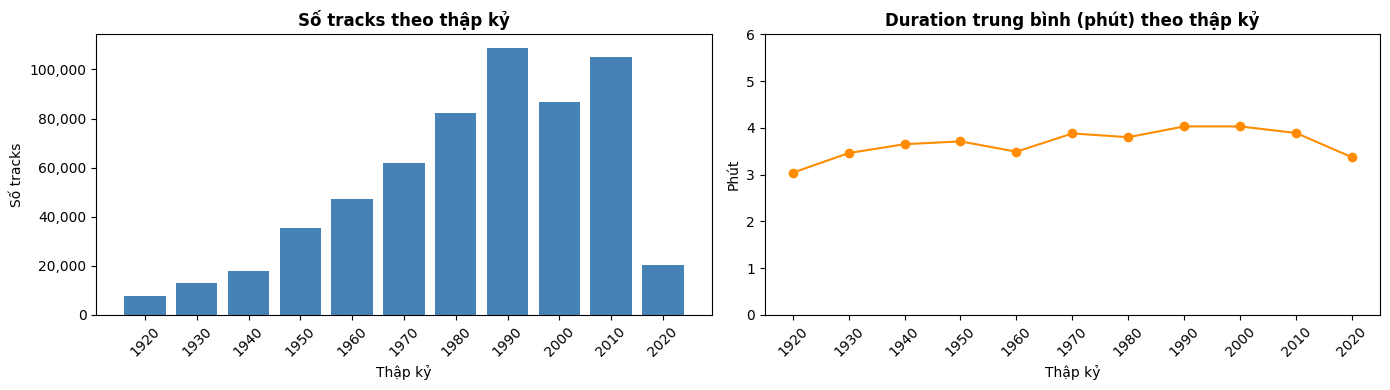

Dataset mất cân bằng thời gian: 1990s (108,875) và 2010s (105,245) chiếm phần lớn.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
decade_labels = df_decade['decade'].astype(str)

# Biểu đồ track count
axes[0].bar(decade_labels, df_decade['track_count'], color='steelblue')
axes[0].set_title('Số tracks theo thập kỷ', fontweight='bold')
axes[0].set_xlabel('Thập kỷ')
axes[0].set_ylabel('Số tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Biểu đồ avg duration
axes[1].plot(decade_labels, df_decade['avg_duration_min'], marker='o', color='darkorange')
axes[1].set_title('Duration trung bình (phút) theo thập kỷ', fontweight='bold')
axes[1].set_xlabel('Thập kỷ')
axes[1].set_ylabel('Phút')
axes[1].set_ylim(0, 6)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()
print(f'Dataset mất cân bằng thời gian: 1990s ({df_decade.loc[df_decade.decade==1990,"track_count"].values[0]:,}) '
      f'và 2010s ({df_decade.loc[df_decade.decade==2010,"track_count"].values[0]:,}) chiếm phần lớn.')

## 2. Explicit Content Ratio theo Thập kỷ

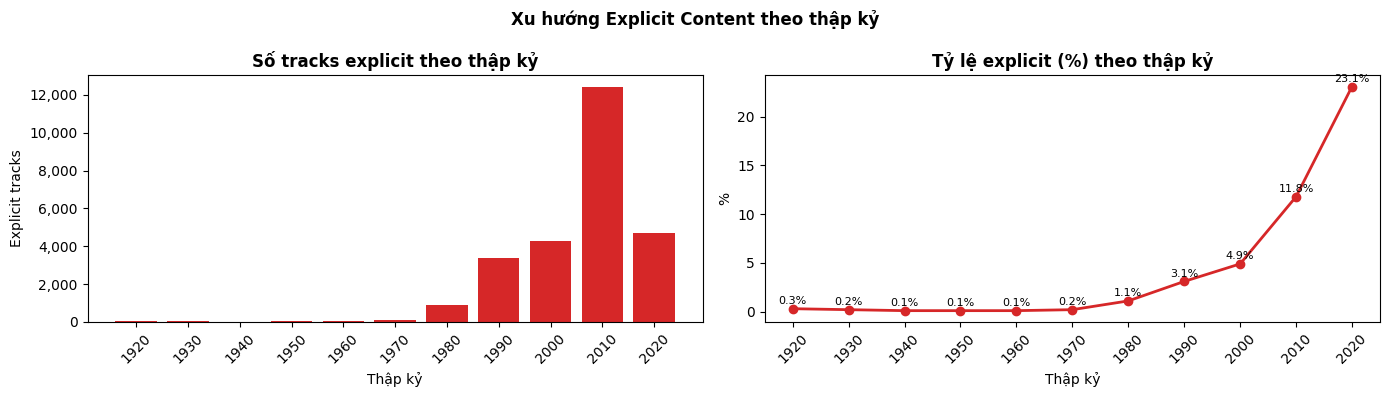

In [4]:
df_explicit = pd.read_sql("""
    SELECT decade, track_count, explicit_count, explicit_ratio
    FROM analytics.vw_explicit_by_decade
    WHERE decade >= 1920
    ORDER BY decade
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart explicit count
axes[0].bar(df_explicit['decade'].astype(str), df_explicit['explicit_count'],
            color='#d62728')
axes[0].set_title('Số tracks explicit theo thập kỷ', fontweight='bold')
axes[0].set_xlabel('Thập kỷ')
axes[0].set_ylabel('Explicit tracks')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Line chart explicit ratio
pct = (df_explicit['explicit_ratio'] * 100).round(1)
axes[1].plot(df_explicit['decade'].astype(str), pct, marker='o', color='#d62728', linewidth=2)
axes[1].set_title('Tỷ lệ explicit (%) theo thập kỷ', fontweight='bold')
axes[1].set_xlabel('Thập kỷ')
axes[1].set_ylabel('%')
for i, (_, row) in enumerate(df_explicit.iterrows()):
    axes[1].text(i, float(pct.iloc[i]) + 0.5, f"{float(pct.iloc[i]):.1f}%",
                 ha='center', fontsize=8)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.suptitle('Xu hướng Explicit Content theo thập kỷ', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Duration Trend theo Năm

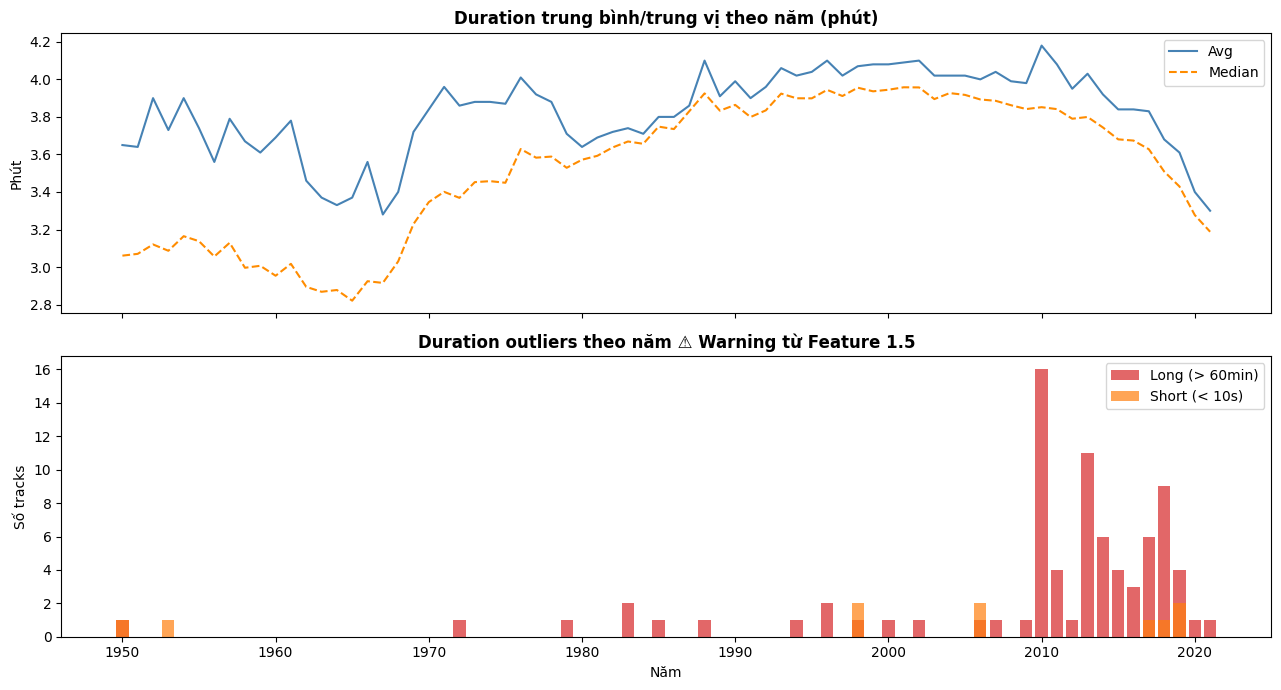

Short tracks (<10s) total: 10
Long tracks (>60min) total: 82


In [5]:
df_dur = pd.read_sql("""
    SELECT release_year, decade, avg_duration_min, median_duration_min,
           short_track_count, long_track_count
    FROM analytics.vw_duration_trends
    WHERE release_year BETWEEN 1950 AND 2021
    ORDER BY release_year
""", conn)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(df_dur['release_year'], df_dur['avg_duration_min'],
             color='steelblue', label='Avg', linewidth=1.5)
axes[0].plot(df_dur['release_year'], df_dur['median_duration_min'],
             color='darkorange', linestyle='--', label='Median', linewidth=1.5)
axes[0].set_title('Duration trung bình/trung vị theo năm (phút)', fontweight='bold')
axes[0].set_ylabel('Phút')
axes[0].legend()

axes[1].bar(df_dur['release_year'], df_dur['long_track_count'],
            color='#d62728', alpha=0.7, label='Long (> 60min)')
axes[1].bar(df_dur['release_year'], df_dur['short_track_count'],
            color='#ff7f0e', alpha=0.7, label='Short (< 10s)')
axes[1].set_title('Duration outliers theo năm ⚠️ Warning từ Feature 1.5', fontweight='bold')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('Số tracks')
axes[1].legend()

plt.tight_layout()
plt.show()

total_short = df_dur['short_track_count'].sum()
total_long  = df_dur['long_track_count'].sum()
print(f'Short tracks (<10s) total: {total_short}')
print(f'Long tracks (>60min) total: {total_long}')

## 4. Nhận xét & Kết luận

**Phân bổ theo thời gian — Mất cân bằng:**
- Dataset **rất lệch về 1990s và 2010s** — lần lượt 108,875 và 105,245 tracks.
- 1920s chỉ có 7,610 tracks (~1.3%) — sparse data cho historical analysis.
- **⚠️ Implication cho ML:** time-based bias sẽ ảnh hưởng nếu model học release_year quá mạnh.

**Explicit content — Xu hướng tăng rõ rệt:**
- Trước 1980s: < 0.2% tracks explicit.
- 1980s → 1.1%, 1990s → 3.1%, 2000s → 4.9%, 2010s → 11.8%, **2020s → 23.1%**.
- Explicit content tăng theo thời gian — có thể là feature hữu ích cho phân tích nhạc hiện đại.

**Duration — Xu hướng tăng nhẹ:**
- Duration trung bình: ~3.3–4.2 phút, tương đối ổn định.
- 2010s avg ≈ 4.2 phút — tracks dài hơn một chút so với 1950–1970 (~3.3–3.7 phút).
- **Duration outliers:** short=26, long=83 — giữ lại theo rule F1.4, cần filter ở EPIC 2 nếu cần.

In [6]:
conn.close()
print('Done — Notebook 04 hoàn thành.')

Done — Notebook 04 hoàn thành.
